<a href="https://colab.research.google.com/github/bburugap/ores5160-2026/blob/main/FinalProject/Bhavya_Burugapalli_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1: Imports and data ingestion

In [88]:

#downloaded all the csv files to laptop and uplaoded to collab and provided the location
#since all data is available in CSV format, no JSON or HTML files were imported
import pandas as pd
import numpy as np
import json
import os
import logging
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# to create a log file
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler("pipeline_audit.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info("Pipeline started")

patients_raw      = pd.read_csv('/content/sample_data/patients.csv', low_memory=False);
encounters_raw    = pd.read_csv('/content/sample_data/encounters.csv', low_memory=False);
conditions_raw    = pd.read_csv('/content/sample_data/conditions.csv', low_memory=False);
medications_raw   = pd.read_csv('/content/sample_data/medications.csv', low_memory=False);
procedures_raw    = pd.read_csv('/content/sample_data/procedures.csv', low_memory=False);
immunizations_raw = pd.read_csv('/content/sample_data/immunizations.csv', low_memory=False);
allergies_raw     = pd.read_csv('/content/sample_data/allergies.csv', low_memory=False);
careplans_raw     = pd.read_csv('/content/sample_data/careplans.csv', low_memory=False);
imaging_raw       = pd.read_csv('/content/sample_data/imaging_studies.csv', low_memory=False);
payer_trans_raw   = pd.read_csv('/content/sample_data/payer_transitions.csv', low_memory=False);
providers_raw     = pd.read_csv('/content/sample_data/providers.csv', low_memory=False);
organizations_raw = pd.read_csv('/content/sample_data/organizations.csv', low_memory=False);
payers_raw        = pd.read_csv('/content/sample_data/payers.csv', low_memory=False);
devices_raw       = pd.read_csv('/content/sample_data/devices.csv', low_memory=False);


In [89]:
# summary of rows/columns for each table
patients_raw.info();
encounters_raw.info();
conditions_raw.info();
medications_raw.info();
procedures_raw.info();
immunizations_raw.info();
allergies_raw.info();
careplans_raw.info();
imaging_raw.info();
payer_trans_raw.info();
providers_raw.info();
organizations_raw.info();
payers_raw.info();
devices_raw.info();


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   1171 non-null   object 
 1   BIRTHDATE            1171 non-null   object 
 2   DEATHDATE            171 non-null    object 
 3   SSN                  1171 non-null   object 
 4   DRIVERS              958 non-null    object 
 5   PASSPORT             898 non-null    object 
 6   PREFIX               927 non-null    object 
 7   FIRST                1171 non-null   object 
 8   LAST                 1171 non-null   object 
 9   SUFFIX               12 non-null     object 
 10  MAIDEN               331 non-null    object 
 11  MARITAL              791 non-null    object 
 12  RACE                 1171 non-null   object 
 13  ETHNICITY            1171 non-null   object 
 14  GENDER               1171 non-null   object 
 15  BIRTHPLACE           1171 non-null   o

## Section 2: Data Cleaning and Transformation



In [91]:
#dropping column, creating new columns(age), coverting dates, assign, NA/UNknown,etc  to missing values

# Clean patients
def clean_patients(df):
    df = df.copy()

    # Drop PHI columns
    cols_to_drop = ["SSN", "DRIVERS", "PASSPORT", "ADDRESS"]
    for col in cols_to_drop:
        if col in df.columns:
            df = df.drop(columns=col)

    # Rename columns
    df = df.rename(columns={
        "Id": "patient_id",
        "BIRTHDATE": "birth_date",
        "DEATHDATE": "death_date",
        "FIRST": "first_name",
        "LAST": "last_name",
        "GENDER": "gender",
        "RACE": "race",
        "ETHNICITY": "ethnicity",
        "CITY": "city",
        "STATE": "state",
        "HEALTHCARE_EXPENSES": "healthcare_expenses"
    })

    # Convert dates
    df["birth_date"] = pd.to_datetime(df["birth_date"], errors="coerce")
    df["death_date"] = pd.to_datetime(df["death_date"], errors="coerce")

    # Create new columns
    ref_date = pd.Timestamp("2026-01-01")
    df["age_years"] = (df["death_date"].fillna(ref_date) - df["birth_date"]).dt.days / 365
    df["is_deceased"] = df["death_date"].notna()

    return df


# Clean encounters
def clean_encounters(df):
    df = df.copy()

    df = df.rename(columns={
        "Id": "encounter_id",
        "START": "enc_start",
        "STOP": "enc_stop",
        "PATIENT": "patient_id",
        "ORGANIZATION": "org_id",
        "PROVIDER": "provider_id",
        "PAYER": "payer_id",
        "ENCOUNTERCLASS": "enc_class",
        "TOTAL_CLAIM_COST": "total_claim_cost",
        "PAYER_COVERAGE": "payer_coverage"
    })

    df["enc_start"] = pd.to_datetime(df["enc_start"], errors="coerce")
    df["enc_stop"] = pd.to_datetime(df["enc_stop"], errors="coerce")

    # Simple duration
    df["duration_hours"] = (df["enc_stop"] - df["enc_start"]).dt.total_seconds() / 3600

    return df

def clean_conditions(df):
    df = df.copy()

    # Rename columns
    df = df.rename(columns={
        "START": "cond_start",
        "STOP": "cond_stop",
        "PATIENT": "patient_id",
        "ENCOUNTER": "encounter_id",
        "CODE": "cond_code",
        "DESCRIPTION": "cond_description"
    })

    # Convert date columns
    df["cond_start"] = pd.to_datetime(df["cond_start"], errors="coerce")
    df["cond_stop"] = pd.to_datetime(df["cond_stop"], errors="coerce")

    # Create active condition flag
    df["is_active"] = df["cond_stop"].isnull()

    # Use a reference date for active conditions
    ref_date = pd.Timestamp("2026-01-01")

    # Calculate condition duration in days
    df["condition_duration_days"] = (
        df["cond_stop"].fillna(ref_date) - df["cond_start"]
    ).dt.days

    return df

# Clean medications
def clean_medications(df):
    df = df.copy()

    # Rename columns (KEEP full mapping)
    df = df.rename(columns={
        "START": "med_start",
        "STOP": "med_stop",
        "PATIENT": "patient_id",
        "PAYER": "payer_id",
        "ENCOUNTER": "encounter_id",
        "CODE": "med_code",
        "DESCRIPTION": "med_description",
        "BASE_COST": "base_cost",
        "PAYER_COVERAGE": "payer_coverage",
        "DISPENSES": "dispenses",
        "TOTALCOST": "total_cost",
        "REASONCODE": "reason_code",
        "REASONDESCRIPTION": "reason_desc"
    })

    # Convert date columns
    df["med_start"] = pd.to_datetime(df["med_start"], errors="coerce")
    df["med_stop"] = pd.to_datetime(df["med_stop"], errors="coerce")

    # Convert numeric columns
    df["total_cost"] = pd.to_numeric(df["total_cost"], errors="coerce")
    df["dispenses"] = pd.to_numeric(df["dispenses"], errors="coerce")

    # Fill missing reason description
    df["reason_desc"] = df["reason_desc"].fillna("Not specified")

    # Create new variable: cost per dispense
    df["cost_per_dispense"] = df["total_cost"] / df["dispenses"]

    return df


# Clean procedures
def clean_procedures(df):
    df = df.copy()

    df = df.rename(columns={
        "DATE": "proc_date",
        "PATIENT": "patient_id",
        "ENCOUNTER": "encounter_id",
        "CODE": "proc_code",
        "DESCRIPTION": "proc_description",
        "BASE_COST": "base_cost",
        "REASONCODE": "reason_code",
        "REASONDESCRIPTION": "reason_desc"
    })

    df["proc_date"] = pd.to_datetime(df["proc_date"], errors="coerce")
    df["base_cost"] = pd.to_numeric(df["base_cost"], errors="coerce")
    df["reason_desc"] = df["reason_desc"].fillna("Not specified")
    df["proc_year"] = df["proc_date"].dt.year

    return df


# Clean imaging
def clean_imaging(df):
    df = df.copy()

    df = df.rename(columns={
        "Id": "imaging_id",
        "DATE": "img_date",
        "PATIENT": "patient_id",
        "ENCOUNTER": "encounter_id",
        "BODYSITE_CODE": "bodysite_code",
        "BODYSITE_DESCRIPTION": "bodysite_desc",
        "MODALITY_CODE": "modality_code",
        "MODALITY_DESCRIPTION": "modality_desc",
        "SOP_CODE": "sop_code",
        "SOP_DESCRIPTION": "sop_desc"
    })

    df["img_date"] = pd.to_datetime(df["img_date"], errors="coerce")
    df["img_year"] = df["img_date"].dt.year

    return df


# Clean organizations
def clean_organizations(df):
    df = df.copy()

    df = df.rename(columns={
        "Id": "org_id",
        "NAME": "org_name"
    })

    return df


# Clean providers
def clean_providers(df):
    df = df.copy()

    df = df.rename(columns={
        "Id": "provider_id",
        "NAME": "provider_name",
        "SPECIALITY": "speciality"
    })

    df["speciality"] = df["speciality"].fillna("Unknown")

    return df

In [92]:
patients = clean_patients(patients_raw)
encounters = clean_encounters(encounters_raw)
conditions = clean_conditions(conditions_raw)
medications = clean_medications(medications_raw)
procedures = clean_procedures(procedures_raw)
imaging = clean_imaging(imaging_raw)
organizations = clean_organizations(organizations_raw)
providers = clean_providers(providers_raw)

## Section 3: Data Quality Validation



In [93]:

#checking for misisng value, negative values, checking date ranges
def check_data_quality(df, table_name):
    print("\nData quality check for:", table_name)
    print("-" * 40)

    # 1. Missing values
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]

    print("Columns with missing values:")
    print(missing_values)

    # 2. Duplicate rows
    duplicate_rows = df.duplicated().sum()
    print("Number of duplicate rows:", duplicate_rows)

    # 3. Negative values in numeric columns
    print("Columns with negative values:")

    numeric_columns = df.select_dtypes(include="number").columns

    for col in numeric_columns:
        negative_count = (df[col] < 0).sum()

        if negative_count > 0:
            print(col, "has", negative_count, "negative values")

    # 4. Date columns outside expected range
    print("Date columns with values outside 1900–2026:")

    date_columns = df.select_dtypes(include="datetime").columns

    for col in date_columns:
        old_dates = (df[col] < pd.Timestamp("1900-01-01")).sum()
        future_dates = (df[col] > pd.Timestamp("2026-12-31")).sum()

        if old_dates > 0 or future_dates > 0:
            print(col, "has", old_dates + future_dates, "date issues")



In [94]:
#negative volumns in some of the tables are becasue of the longitude represntation
check_data_quality(patients, "patients")
check_data_quality(encounters, "encounters")
check_data_quality(conditions, "conditions")
check_data_quality(medications, "medications")
check_data_quality(procedures, "procedures")
check_data_quality(allergies, "allergies")
check_data_quality(careplans, "careplans")
check_data_quality(imaging, "imaging")
check_data_quality(organizations, "organizations")
check_data_quality(providers, "providers")


Data quality check for: patients
----------------------------------------
Columns with missing values:
death_date    1000
PREFIX         244
SUFFIX        1159
MAIDEN         840
MARITAL        380
ZIP            543
dtype: int64
Number of duplicate rows: 0
Columns with negative values:
LON has 1171 negative values
Date columns with values outside 1900–2026:

Data quality check for: encounters
----------------------------------------
Columns with missing values:
REASONCODE           39569
REASONDESCRIPTION    39569
dtype: int64
Number of duplicate rows: 0
Columns with negative values:
Date columns with values outside 1900–2026:

Data quality check for: conditions
----------------------------------------
Columns with missing values:
cond_stop    3811
dtype: int64
Number of duplicate rows: 0
Columns with negative values:
Date columns with values outside 1900–2026:

Data quality check for: medications
----------------------------------------
Columns with missing values:
med_stop        1

## Section 4: Reshaping and Integration


In [95]:

#Merging encounters, patient, rovider, organizaion,and payer tables to create one table

# create copy of encoutners
enc_fact = encounters.copy()

# Add patient details
patient_cols = patients[["patient_id", "first_name", "last_name", "birth_date",
                          "gender", "race", "ethnicity", "city", "state",
                          "healthcare_expenses"]]
enc_fact = enc_fact.merge(patient_cols, on="patient_id", how="left")

#Add organization name
org_cols = organizations[["org_id", "org_name"]]
enc_fact = enc_fact.merge(org_cols, on="org_id", how="left")

# Add provider name and speciality
prov_cols = providers[["provider_id", "provider_name", "speciality"]]
enc_fact = enc_fact.merge(prov_cols, on="provider_id", how="left")

# Add payer name
payer_lookup = payers_raw[["Id", "NAME"]].rename(columns={"Id": "payer_id", "NAME": "payer_name"})
enc_fact = enc_fact.merge(payer_lookup, on="payer_id", how="left")

# Assing unknown to unmatched records
enc_fact["payer_name"]    = enc_fact["payer_name"].fillna("Unknown")
enc_fact["org_name"]      = enc_fact["org_name"].fillna("Unknown")
enc_fact["provider_name"] = enc_fact["provider_name"].fillna("Unknown")

print("Encounter Fact Table shape:", enc_fact.shape)
enc_fact[["encounter_id", "enc_class", "enc_start", "first_name",
          "last_name", "gender", "payer_name", "total_claim_cost"]].head(5)


Encounter Fact Table shape: (53346, 29)


,encounter_id,enc_class,enc_start,first_name,last_name,gender,payer_name,total_claim_cost
0,d0c40d10-8d87-447e-836e-99d26ad52ea5,ambulatory,2010-01-23 17:45:28+00:00,Milo271,Feil794,M,Blue Cross Blue Shield,129.16
1,e88bc3a9-007c-405e-aabc-792a38f4aa2b,wellness,2012-01-23 17:45:28+00:00,Milo271,Feil794,M,Blue Cross Blue Shield,129.16
2,8f104aa7-4ca9-4473-885a-bba2437df588,ambulatory,2001-05-01 15:02:18+00:00,José Eduardo181,Gómez206,M,NO_INSURANCE,129.16
3,b85c339a-6076-43ed-b9d0-9cf013dec49d,wellness,2011-07-28 15:02:18+00:00,José Eduardo181,Gómez206,M,NO_INSURANCE,129.16
4,dae2b7cb-1316-4b78-954f-fa610a6c6d0e,wellness,2010-07-27 12:58:08+00:00,Jayson808,Fadel536,M,Humana,129.16


In [96]:
# Create a pivot table showing how many encounters of each type
# happened in each year. This gives a year-by-year breakdown.

# Make sure enc_start is a date
encounters["enc_start"] = pd.to_datetime(encounters["enc_start"], errors="coerce")

# Create year from enc_start
encounters["year"] = encounters["enc_start"].dt.year

# Group by year and encounter class
enc_grouped = encounters.groupby(["year", "enc_class"]).size().reset_index(name="count")

# Create pivot table
enc_pivot = enc_grouped.pivot(index="year", columns="enc_class", values="count")

# Fill missing values with 0
enc_pivot = enc_pivot.fillna(0)

print("Encounter Counts by Class and Year")
print(enc_pivot.tail(8))

Encounter Counts by Class and Year
enc_class  ambulatory  emergency  inpatient  outpatient  urgentcare  wellness
year                                                                         
2013           1194.0      159.0      104.0       561.0       141.0     899.0
2014           1369.0      159.0      109.0       539.0       145.0     857.0
2015           1252.0      147.0      112.0       515.0       147.0     890.0
2016           1305.0      133.0       95.0       578.0       151.0     886.0
2017           1277.0      157.0       87.0       542.0       173.0     917.0
2018           1153.0      125.0      140.0       589.0       151.0     932.0
2019           1007.0      125.0      122.0       562.0       170.0     933.0
2020            384.0       39.0       36.0       175.0        58.0     269.0


## Section 5: Summary Statistics

In [97]:
print("=== Patient Demographics ===")
print(f"  Total patients: {len(patients):,}")
print(f"  Deceased: {patients['is_deceased'].sum():,} ({patients['is_deceased'].mean()*100:.1f}%)")
print(f"  Mean age: {patients['age_years'].mean():.1f} yrs")
print(f"  Median age: {patients['age_years'].median():.1f} yrs")
print(f"  min age: {patients['age_years'].min():.1f} yrs")
print(f"  max age: {patients['age_years'].max():.1f} yrs")
print(f"\nGender:\n{patients['gender'].value_counts().to_string()}")
print(f"\nRace:\n{patients['race'].value_counts().to_string()}")

print("\n=== Encounters ===")
print(f"  Total: {len(encounters):,}")
print(f"  Date range: {encounters['enc_start'].min().date()} to {encounters['enc_start'].max().date()}")
print(f"  Mean payer coverage: ${encounters['payer_coverage'].mean():,.2f}")
print(f"\nEncounter classes:\n{encounters['enc_class'].value_counts().to_string()}")

print("\n=== Conditions ===")
print(f"  Total records: {len(conditions):,}")
print(f"  Unique conditions: {conditions['cond_description'].nunique():,}")
print(f"  Currently active: {conditions['is_active'].sum():,}")

print("\n=== Medications ===")
print(f"  Total records: {len(medications):,}")
print(f"  Unique medications: {medications['med_description'].nunique():,}")
print(f"  Median total cost: ${medications['total_cost'].median():,.2f}")
print(f"  Mean total cost: ${medications['total_cost'].mean():,.2f}")

print("\n=== Procedures ===")
print(f"  Total records: {len(procedures):,}")
print(f"  Unique procedures: {procedures['proc_description'].nunique():,}")
print(f"  Median base cost: ${procedures['base_cost'].median():,.2f}")
print(f"  Mean base cost: ${procedures['base_cost'].mean():,.2f}")

=== Patient Demographics ===
  Total patients: 1,171
  Deceased: 171 (14.6%)
  Mean age: 46.5 yrs
  Median age: 46.8 yrs
  min age: 0.8 yrs
  max age: 116.1 yrs

Gender:
gender
F    609
M    562

Race:
race
white     965
black     101
asian      90
native     13
other       2

=== Encounters ===
  Total: 53,346
  Date range: 1912-07-21 to 2020-04-28
  Mean payer coverage: $62.00

Encounter classes:
enc_class
wellness      19106
ambulatory    18936
outpatient     9003
urgentcare     2373
emergency      2090
inpatient      1838

=== Conditions ===
  Total records: 8,376
  Unique conditions: 129
  Currently active: 3,811

=== Medications ===
  Total records: 42,989
  Unique medications: 134
  Median total cost: $526.98
  Mean total cost: $2,328.65

=== Procedures ===
  Total records: 34,981
  Unique procedures: 144
  Median base cost: $2,337.58
  Mean base cost: $4,930.76


## Section 6: Visualizations and Analysis

This section includes 14 visualizations across five categories:
1. Demographics
2. Clinical patterns
3. Cost and financial analysis
4. Outlier detection
5. Advanced analytical insights


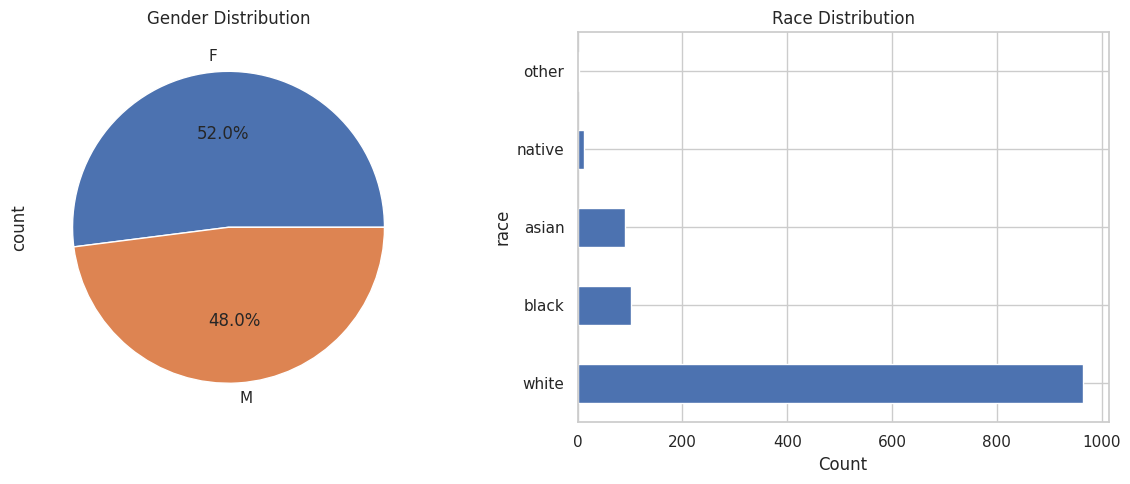

In [99]:

# genedr and race distribution
# Create two plots side by side
plt.figure(figsize=(12, 5))

# Gender pie chart
plt.subplot(1, 2, 1)
patients["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")

# Race bar chart
plt.subplot(1, 2, 2)
patients["race"].value_counts().plot(kind="barh")
plt.title("Race Distribution")
plt.xlabel("Count")

plt.tight_layout()
plt.show()

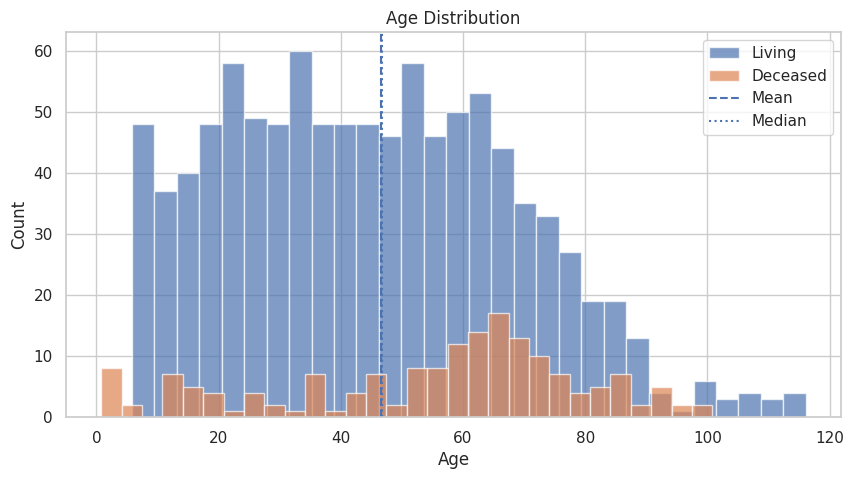

In [100]:

# age distribution of living and deceasesd popln

# Separate living and deceased
living = patients[patients["is_deceased"] == False]["age_years"]
deceased = patients[patients["is_deceased"] == True]["age_years"]

# Plot histogram
plt.figure(figsize=(10, 5))

plt.hist(living, bins=30, alpha=0.7, label="Living")
plt.hist(deceased, bins=30, alpha=0.7, label="Deceased")

# Mean and median lines
plt.axvline(patients["age_years"].mean(), linestyle="--", label="Mean")
plt.axvline(patients["age_years"].median(), linestyle=":", label="Median")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.legend()
plt.show()

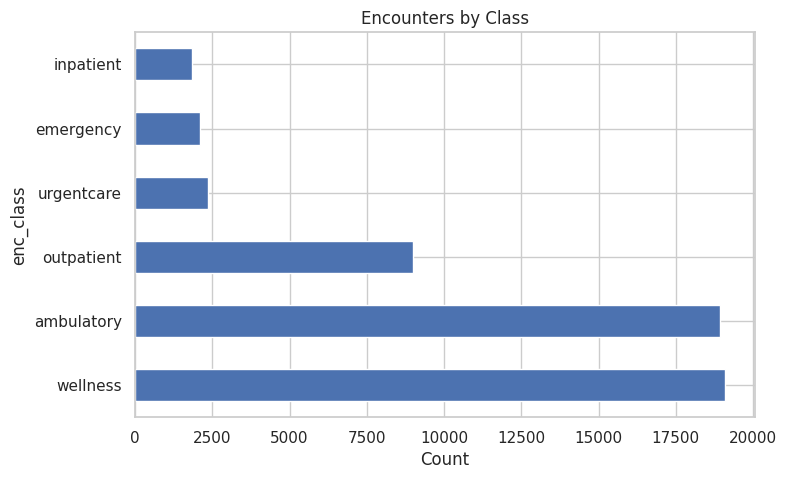

In [101]:
#Number of encounters by the encounter class

# Count encounters by class
enc_counts = encounters["enc_class"].value_counts()

# Plot
plt.figure(figsize=(8, 5))
enc_counts.plot(kind="barh")

plt.title("Encounters by Class")
plt.xlabel("Count")

plt.show()

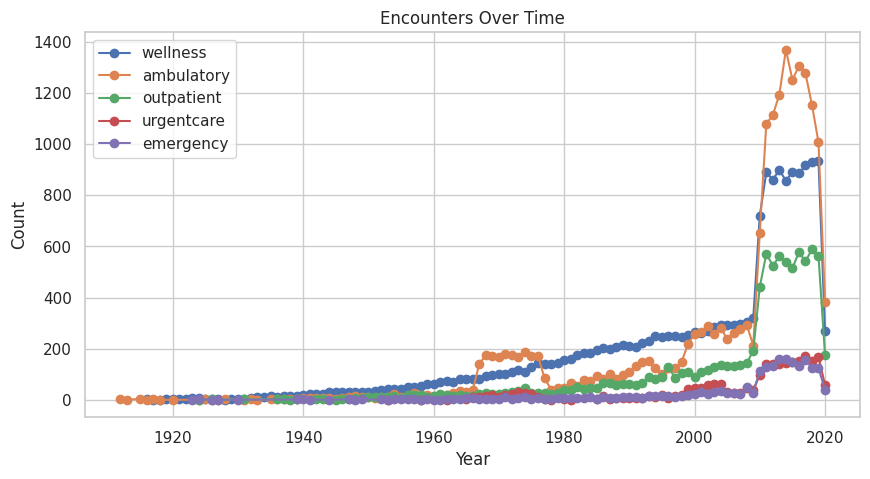

In [102]:

#Time series analyiss of encounters over time

# Create year from enc_start
encounters["enc_start"] = pd.to_datetime(encounters["enc_start"], errors="coerce")
encounters["enc_year"] = encounters["enc_start"].dt.year

# Get top 5 encounter classes
top5 = encounters["enc_class"].value_counts().head(5).index

# Filter data
data = encounters[encounters["enc_class"].isin(top5)]

# Group data
grouped = data.groupby(["enc_year", "enc_class"]).size().reset_index(name="count")

# Plot
plt.figure(figsize=(10, 5))

for cls in top5:
    temp = grouped[grouped["enc_class"] == cls]
    plt.plot(temp["enc_year"], temp["count"], marker="o", label=cls)

plt.title("Encounters Over Time")
plt.xlabel("Year")
plt.ylabel("Count")

plt.legend()
plt.show()

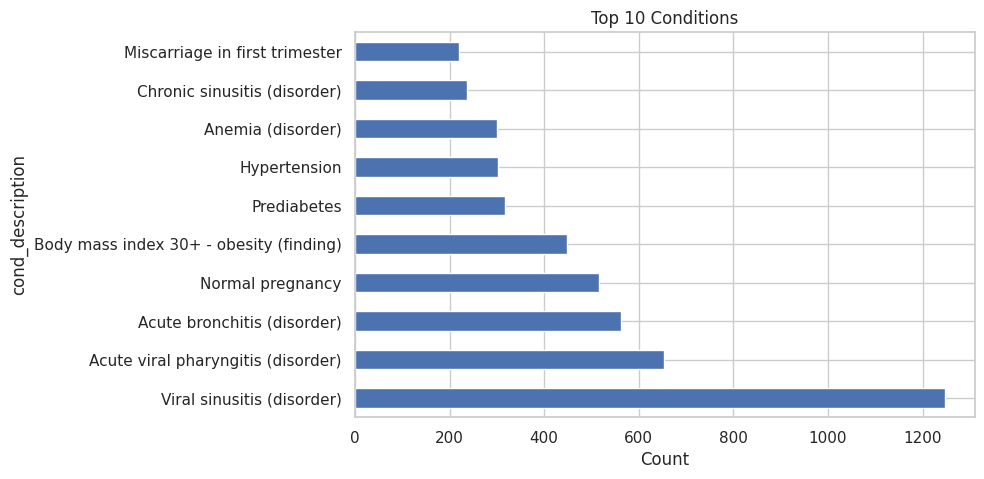

In [103]:

#Top conditions by the count of conditions
# Get top 10 conditions
top10 = conditions["cond_description"].value_counts().head(10)

# Plot
plt.figure(figsize=(8, 5))
top10.plot(kind="barh")

plt.title("Top 10 Conditions")
plt.xlabel("Count")

plt.show()

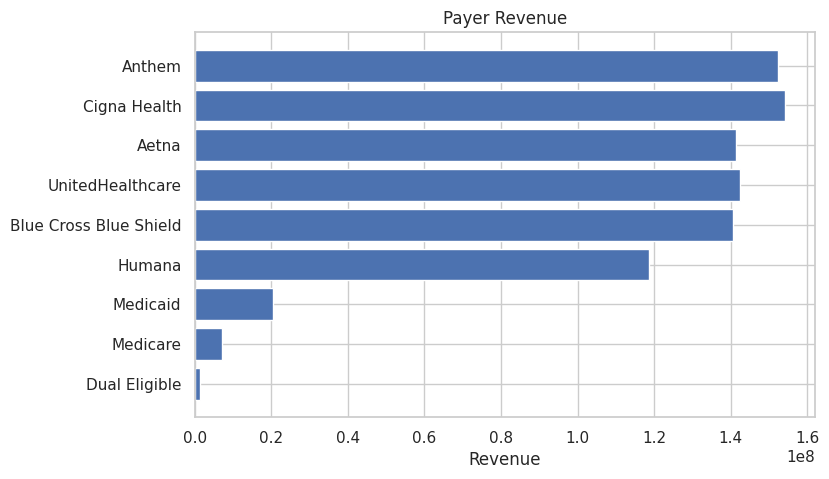

In [68]:

#top insruane providers by revenue
# Filter and sort data
payer_rev = payers_raw[["NAME", "REVENUE"]]
payer_rev = payer_rev[payer_rev["REVENUE"] > 0]

# Plot
plt.figure(figsize=(8, 5))
plt.barh(payer_rev["NAME"], payer_rev["REVENUE"])

plt.title("Payer Revenue")
plt.xlabel("Revenue")

plt.show()

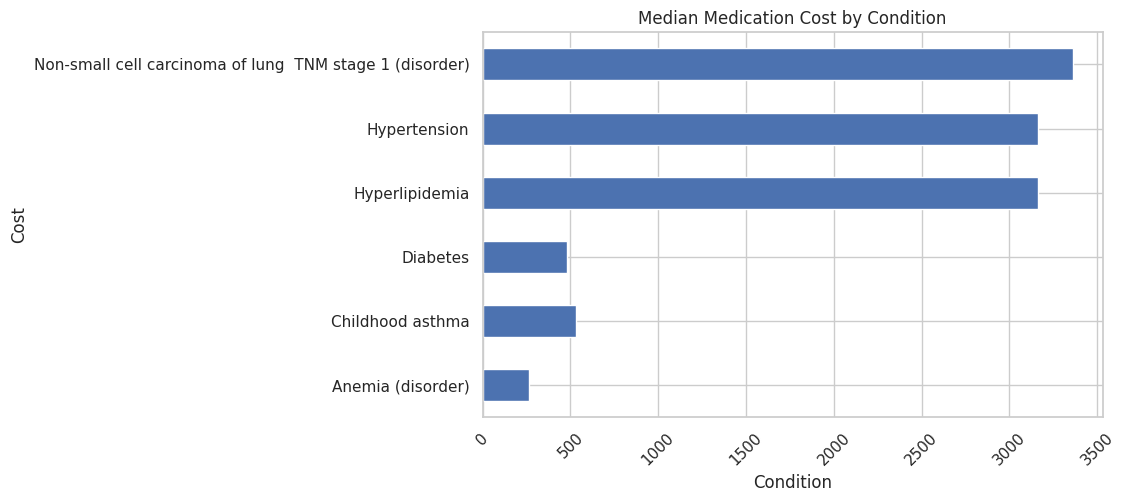

In [83]:

#top medications costs assocaited with its corresponding condition

# Remove "Not specified"
data = medications[medications["reason_desc"] != "Not specified"]

# Take top 6
top10 = data["reason_desc"].value_counts().head(6).index

# Filter
data = data[data["reason_desc"].isin(top10)]

# Median cost
median_cost = data.groupby("reason_desc")["total_cost"].median()

# Plot
plt.figure(figsize=(8, 5))
median_cost.plot(kind="barh")

plt.title("Median Medication Cost by Condition")
plt.xlabel("Condition")
plt.ylabel("Cost")

plt.xticks(rotation=45)
plt.show()

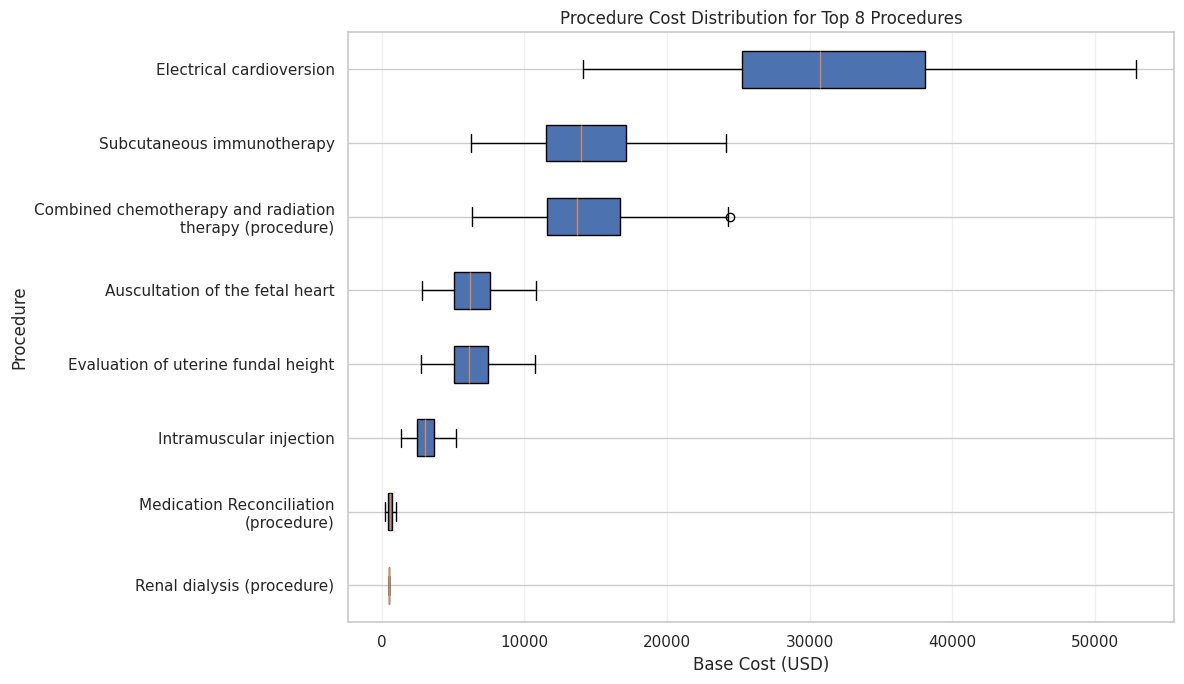

In [75]:


#cost distribution of preocdeures for the top procedures by cost
import textwrap

# Get top 8 procedures
top8 = procedures["proc_description"].value_counts().head(8).index

# Keep only top 8 procedures
data = procedures[procedures["proc_description"].isin(top8)].copy()

# Make procedure names shorter/wrapped for display
data["procedure_label"] = data["proc_description"].apply(
    lambda x: "\n".join(textwrap.wrap(x, 35))
)

# Order labels by median cost
order = (
    data.groupby("procedure_label")["base_cost"]
    .median()
    .sort_values()
    .index
)

# Create data list for boxplot
box_data = []
for procedure in order:
    costs = data[data["procedure_label"] == procedure]["base_cost"].dropna()
    box_data.append(costs)

# Plot horizontal boxplot
plt.figure(figsize=(12, 7))

plt.boxplot(
    box_data,
    labels=order,
    vert=False,
    showfliers=True,
    patch_artist=True
)

plt.title("Procedure Cost Distribution for Top 8 Procedures")
plt.xlabel("Base Cost (USD)")
plt.ylabel("Procedure")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [86]:
#Identifying outlier medications by cost and plotting these outliers on a scatter plot

# Medication cost outlier check using IQR
q1 = medications["total_cost"].quantile(0.25)
q3 = medications["total_cost"].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

print("Medication Cost Outlier Check")
print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Upper limit:", round(upper_limit, 2))

# Find outlier medication records
outlier_meds = medications[medications["total_cost"] > upper_limit]

print("\nNumber of outlier records:", len(outlier_meds))

# Show top outlier medications by average cost
top_outlier_meds = (
    outlier_meds
    .groupby("med_description")["total_cost"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 outlier medications by average cost:")
print(top_outlier_meds)

Medication Cost Outlier Check
Q1: 263.49
Q3: 3161.88
IQR: 2898.39
Upper limit: 7509.47

Number of outlier records: 1031

Top 10 outlier medications by average cost:
med_description
Acetaminophen 325 MG / oxyCODONE Hydrochloride 5 MG Oral Tablet    404147.621667
10 ML oxaliplatin 5 MG/ML Injection                                185755.624000
FLUoxetine 20 MG Oral Capsule                                      182598.570000
Acetaminophen/Hydrocodone                                          176274.810000
Sertraline 100 MG Oral Tablet                                      154317.310000
Tacrine 10 MG Oral Capsule                                         142050.732000
24hr nicotine transdermal patch                                    112472.588571
Diazepam 5 MG Oral Tablet                                          106803.297500
Vitamin B 12 5 MG/ML Injectable Solution                            98028.414231
ferrous sulfate 325 MG Oral Tablet                                  82064.587857
Name: tot

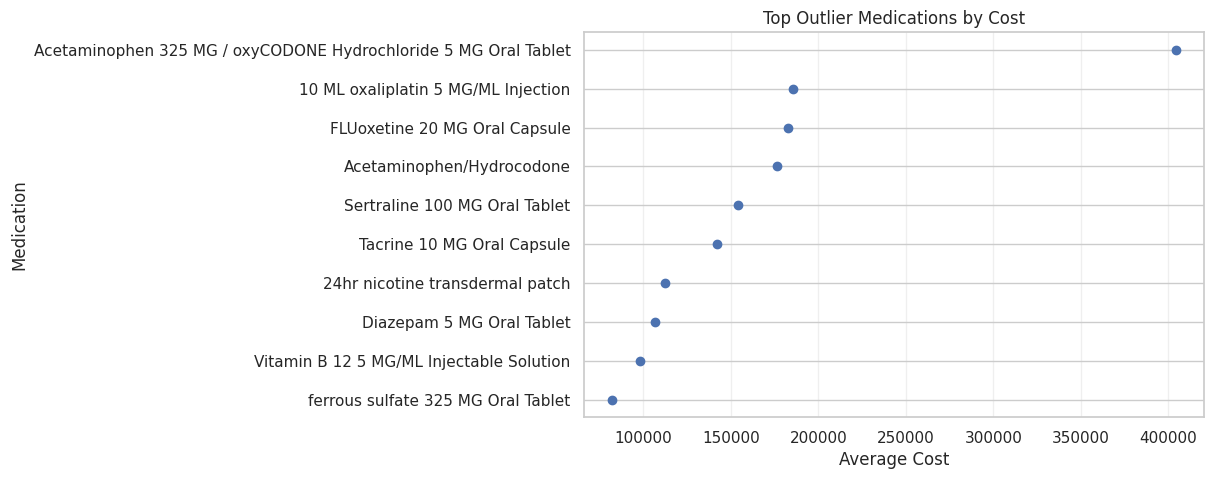

In [87]:
data = top_outlier_meds.sort_values()

plt.figure(figsize=(8, 5))

# Create dot plot
plt.scatter(data.values, data.index)

plt.title("Top Outlier Medications by Cost")
plt.xlabel("Average Cost")
plt.ylabel("Medication")

plt.grid(axis="x", alpha=0.3)

plt.show()

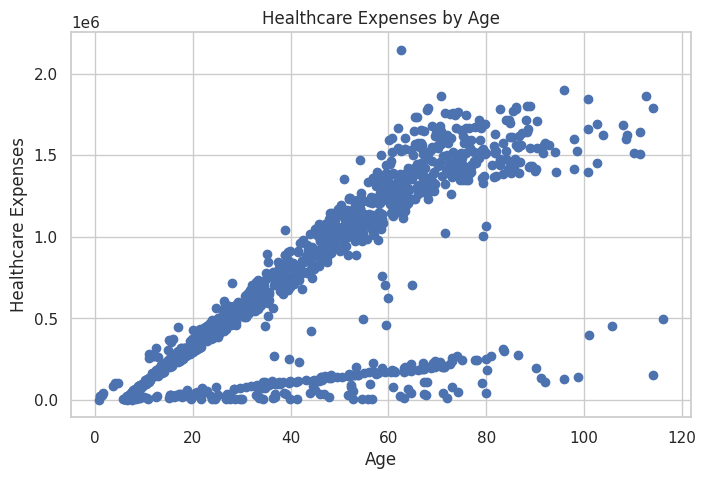

In [73]:

#plotting Healthcare expense against age
plt.figure(figsize=(8, 5))

plt.scatter(patients["age_years"], patients["healthcare_expenses"])

plt.title("Healthcare Expenses by Age")
plt.xlabel("Age")
plt.ylabel("Healthcare Expenses")

plt.show()

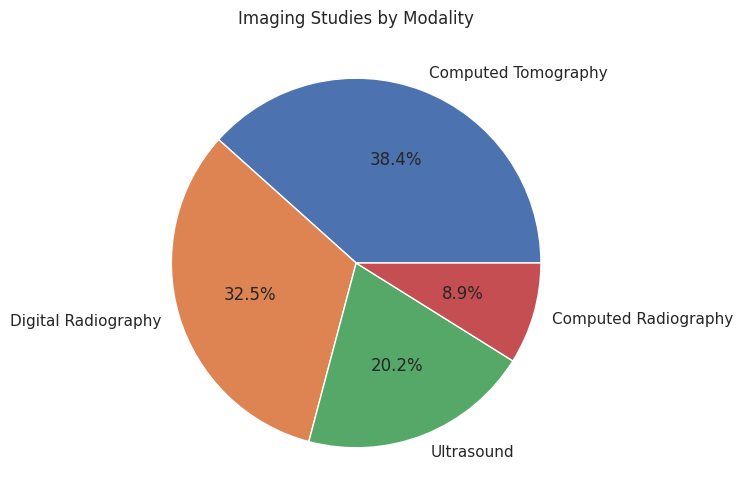

In [84]:
Imaging distbrution

# Count modalities
mod_counts = imaging["modality_desc"].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
mod_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Imaging Studies by Modality")

plt.ylabel("")  # removes extra label
plt.show()

Top specialities:
speciality
GENERAL PRACTICE          1120
INTERNAL MEDICINE          608
NURSE PRACTITIONER         511
CLINICAL SOCIAL WORKER     367
PHYSICIAN ASSISTANT        311
PHYSICAL THERAPY           308
FAMILY PRACTICE            279
CLINICAL PSYCHOLOGIST      204
DIAGNOSTIC RADIOLOGY       171
CHIROPRACTIC               148
OPTOMETRY                  139
PSYCHIATRY                 125
Name: count, dtype: int64


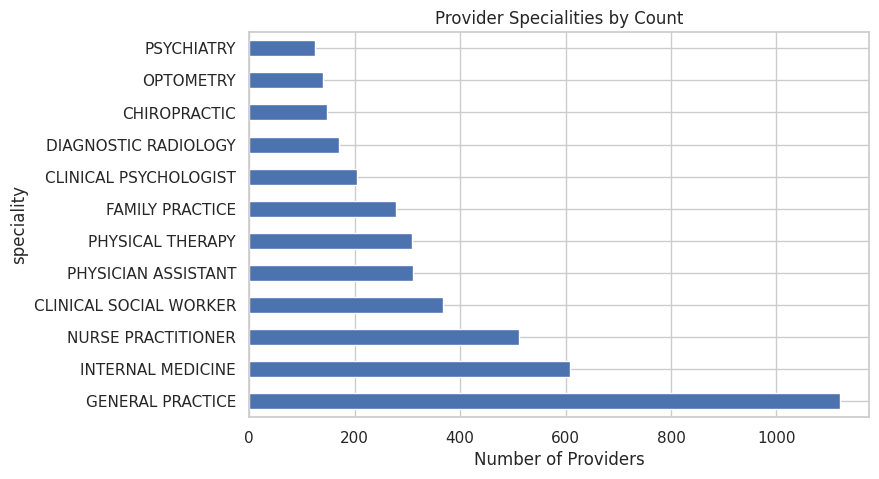

In [85]:
# Count providers by speciality (top 12)
spec_counts = providers["speciality"].value_counts().head(12)

print("Top specialities:")
print(spec_counts)

# Plot
plt.figure(figsize=(8, 5))
spec_counts.plot(kind="barh")

plt.title("Provider Specialities by Count")
plt.xlabel("Number of Providers")

plt.show()


## Section 7: Pipeline Design, Governance & Lineage

---

The diagram below shows the end-to-end pipeline

```
[Raw Data]
Raw Sources — 14 Synthea CSV files]
              |
              v
[Ingestion]
pd.read_csv() for all 14 tables
Schema check — confirm required columns exist
              |
              v                          
[Cleaning — 8 tables cleaned]
clean_patients()       clean_encounters()
clean_conditions()     clean_medications()
clean_procedures()     clean_imaging()
clean_organizations()  clean_providers()
→ column renaming, datetime parsing,
null fills, derived columns
              |
              v                      
[Validation]
check_data_quality()
→ null counts, duplicate detection,
negative values, date range checks
              |
              v                    
[Reshaping]
merge()  → enc_fact (denormalized encounter fact table)
pivot()  → enc_pivot (encounter counts by year and class)
              |
              v                   
[Summary Statistics + Visualizations]
Summary statistics — patient, encounter, condition, medication counts
14 figures — demographics, clinical trends, costs, outliers
              |
              v                   
[Lineage Log]
data_lineage.csv — every step recorded with row counts and timestamp
pipeline_audit.log — real-time INFO and WARNING messages
```

Note:In a production environment this pipeline would be scheduled using a tool such as Apache Airflow.

---

#7.2 Data Governance Plan

#Versioning Strategy
The pipeline is versioned at v.1. Every run stamps 'pipeline_version' and 'author' into the lineage log.

Schema changes (e.g., adding a new derived column) increment the minor version: v1.0 -> v1.1.


#Data Governance
| Component | Implementation in This Pipeline |
|---|---|
| **Identify organization structure** | Five defined roles; see Roles table below |
| **Identify relevant stakeholders** | Data Owner, Steward, Consumer, IT, Compliance Officer |
| **Identify scope of data** | 14 Synthea CSV tables, approx 157,000 total records, Massachusetts synthetic population |
| **Optimize and compute** | Batch pipeline scheduled weekly; clean tables overwrite previous run |
| **Measure and monitor quality** | check_data_quality() runs on all 12 tables - nulls, duplicates, negatives, date ranges |
| **Store the data** | Clean CSV outputs stored in project folder|
| **Communicate** | Summary report and visualizations shared with clinical analytics team |


#### Roles and Responsibilities

| Role | Person / Team | Responsibilities |
|---|---|---|
| **Data Owner** | Health Informatics Dept. | Approves schema changes, defines access policies, ensures HIPAA compliance |
| **Data Steward** | Bhavya Burugapalli | Maintains pipeline code, updates lineage log, monitors quality checks, documents all transformations |
| **Data Consumer** | Clinical Analytics Team | Uses clean tables for reporting, dashboards, and population health research |
| **IT / Infrastructure** | Cloud Engineering | Manages storage, compute, and pipeline scheduling |
| **Compliance Officer** | Legal / Privacy Team | Reviews de-identification; ensures HIPAA Safe Harbor standards are met |


#### How Data Changes Are Tracked
- Every transformation step is written to 'data_lineage.csv' with step number, action, source, output, row counts, timestamp, version, and author
- All INFO and WARNING messages are written in real time to 'pipeline_audit.log'
- PII columns (SSN, DRIVERS, PASSPORT) are dropped in 'clean_patients()' before any analysis


---

#7.3 Data Lineage Log


In [106]:
# Data Lineage Log
# This records every step of the pipeline — what data came in,
# what action was taken, what came out, and how many rows.

steps = [
    #Ingestion - all 14 CSV tables loaded
    (1,  "Ingest CSV", "patients.csv",          "patients_raw",      len(patients_raw),      len(patients_raw)),
    (2,  "Ingest CSV", "encounters.csv",         "encounters_raw",    len(encounters_raw),    len(encounters_raw)),
    (3,  "Ingest CSV", "conditions.csv",         "conditions_raw",    len(conditions_raw),    len(conditions_raw)),
    (4,  "Ingest CSV", "medications.csv",        "medications_raw",   len(medications_raw),   len(medications_raw)),
    (5,  "Ingest CSV", "procedures.csv",         "procedures_raw",    len(procedures_raw),    len(procedures_raw)),
    (6,  "Ingest CSV", "immunizations.csv",      "immunizations_raw", len(immunizations_raw), len(immunizations_raw)),
    (7,  "Ingest CSV", "allergies.csv",          "allergies_raw",     len(allergies_raw),     len(allergies_raw)),
    (8,  "Ingest CSV", "careplans.csv",          "careplans_raw",     len(careplans_raw),     len(careplans_raw)),
    (9,  "Ingest CSV", "imaging_studies.csv",    "imaging_raw",       len(imaging_raw),       len(imaging_raw)),
    (10, "Ingest CSV", "payer_transitions.csv",  "payer_trans_raw",   len(payer_trans_raw),   len(payer_trans_raw)),
    (11, "Ingest CSV", "providers.csv",          "providers_raw",     len(providers_raw),     len(providers_raw)),
    (12, "Ingest CSV", "organizations.csv",      "organizations_raw", len(organizations_raw), len(organizations_raw)),
    (13, "Ingest CSV", "payers.csv",             "payers_raw",        len(payers_raw),        len(payers_raw)),
    (14, "Ingest CSV", "devices.csv",            "devices_raw",       len(devices_raw),       len(devices_raw)),

    #Cleaning only the 8 tables that were cleaned
    (15, "Clean",      "patients_raw",           "patients",          len(patients_raw),      len(patients)),
    (16, "Clean",      "encounters_raw",         "encounters",        len(encounters_raw),    len(encounters)),
    (17, "Clean",      "conditions_raw",         "conditions",        len(conditions_raw),    len(conditions)),
    (18, "Clean",      "medications_raw",        "medications",       len(medications_raw),   len(medications)),
    (19, "Clean",      "procedures_raw",         "procedures",        len(procedures_raw),    len(procedures)),
    (20, "Clean",      "imaging_raw",            "imaging",           len(imaging_raw),       len(imaging)),
    (21, "Clean",      "organizations_raw",      "organizations",     len(organizations_raw), len(organizations)),
    (22, "Clean",      "providers_raw",          "providers",         len(providers_raw),     len(providers)),

    #Validation, Reshaping, Visualization
    (23, "Validate",   "all cleaned tables",     "qc_reports",        0,                      0),
    (24, "Merge",      "enc + patients + org",   "enc_fact",          len(encounters),        len(enc_fact)),
    (25, "Pivot",      "encounters",             "enc_pivot",         len(encounters),        len(enc_pivot)),
    (26, "Visualize",  "cleaned tables",         "14 figure files",   0,                      0),
]

lineage_df = pd.DataFrame(
    steps,
    columns=["step", "action", "source", "output", "rows_in", "rows_out"]
)

lineage_df["timestamp"]        = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
lineage_df["pipeline_version"] = "v1.0"
lineage_df["author"]           = "Bhavya Burugapalli"

lineage_df.to_csv("data_lineage.csv", index=False)
print("Lineage log saved to data_lineage.csv")
print()
print(lineage_df[["step", "action", "source", "output", "rows_in", "rows_out"]].to_string(index=False))

Lineage log saved to data_lineage.csv

 step     action                source            output  rows_in  rows_out
    1 Ingest CSV          patients.csv      patients_raw     1171      1171
    2 Ingest CSV        encounters.csv    encounters_raw    53346     53346
    3 Ingest CSV        conditions.csv    conditions_raw     8376      8376
    4 Ingest CSV       medications.csv   medications_raw    42989     42989
    5 Ingest CSV        procedures.csv    procedures_raw    34981     34981
    6 Ingest CSV     immunizations.csv immunizations_raw    15478     15478
    7 Ingest CSV         allergies.csv     allergies_raw      597       597
    8 Ingest CSV         careplans.csv     careplans_raw     3483      3483
    9 Ingest CSV   imaging_studies.csv       imaging_raw      855       855
   10 Ingest CSV payer_transitions.csv   payer_trans_raw     3801      3801
   11 Ingest CSV         providers.csv     providers_raw     5855      5855
   12 Ingest CSV     organizations.csv organizati

## Pipeline Complete

**Outputs produced by this pipeline:**

| File | Description |
|---|---|
| `data_lineage.csv` | 33-step lineage log with timestamps, row counts, and version |
| `pipeline_audit.log` | Real-time INFO and WARNING audit trail |
| `fig01–fig14 .png` | 14 visualization files |

---
